# CodeAlpha Data Analytics Internship
# TASK 4: Sentiment Analysis
# Source : Amazon-style product reviews (built-in sample)
# Method : VADER (rule-based NLP — no training needed)
# Dataset: Titanic (via seaborn built-in)
# Author: Aisha Arif

       SENTIMENT ANALYSIS — PRODUCT REVIEWS
      Product                                                                    Review  compound Sentiment
 Laptop Pro X Absolutely love this laptop! Battery life is amazing and it's super fast.    0.9258  Positive
 Laptop Pro X          Best purchase I've made this year. Highly recommend to everyone!    0.8066  Positive
Wireless Buds            Crystal clear sound quality. Very comfortable to wear all day.    0.7346  Positive
Wireless Buds                       Fantastic earbuds! Noise cancellation is top-notch.    0.5983  Positive
  Smart Watch           Looks great and works perfectly. Very happy with this purchase.    0.9230  Positive
  Smart Watch           Excellent build quality. The fitness tracking is very accurate.    0.7003  Positive
     Tablet Z             Incredible display and smooth performance. Worth every penny!    0.2942  Positive
     Tablet Z                         Amazingly fast and lightweight. Great for travel.    0

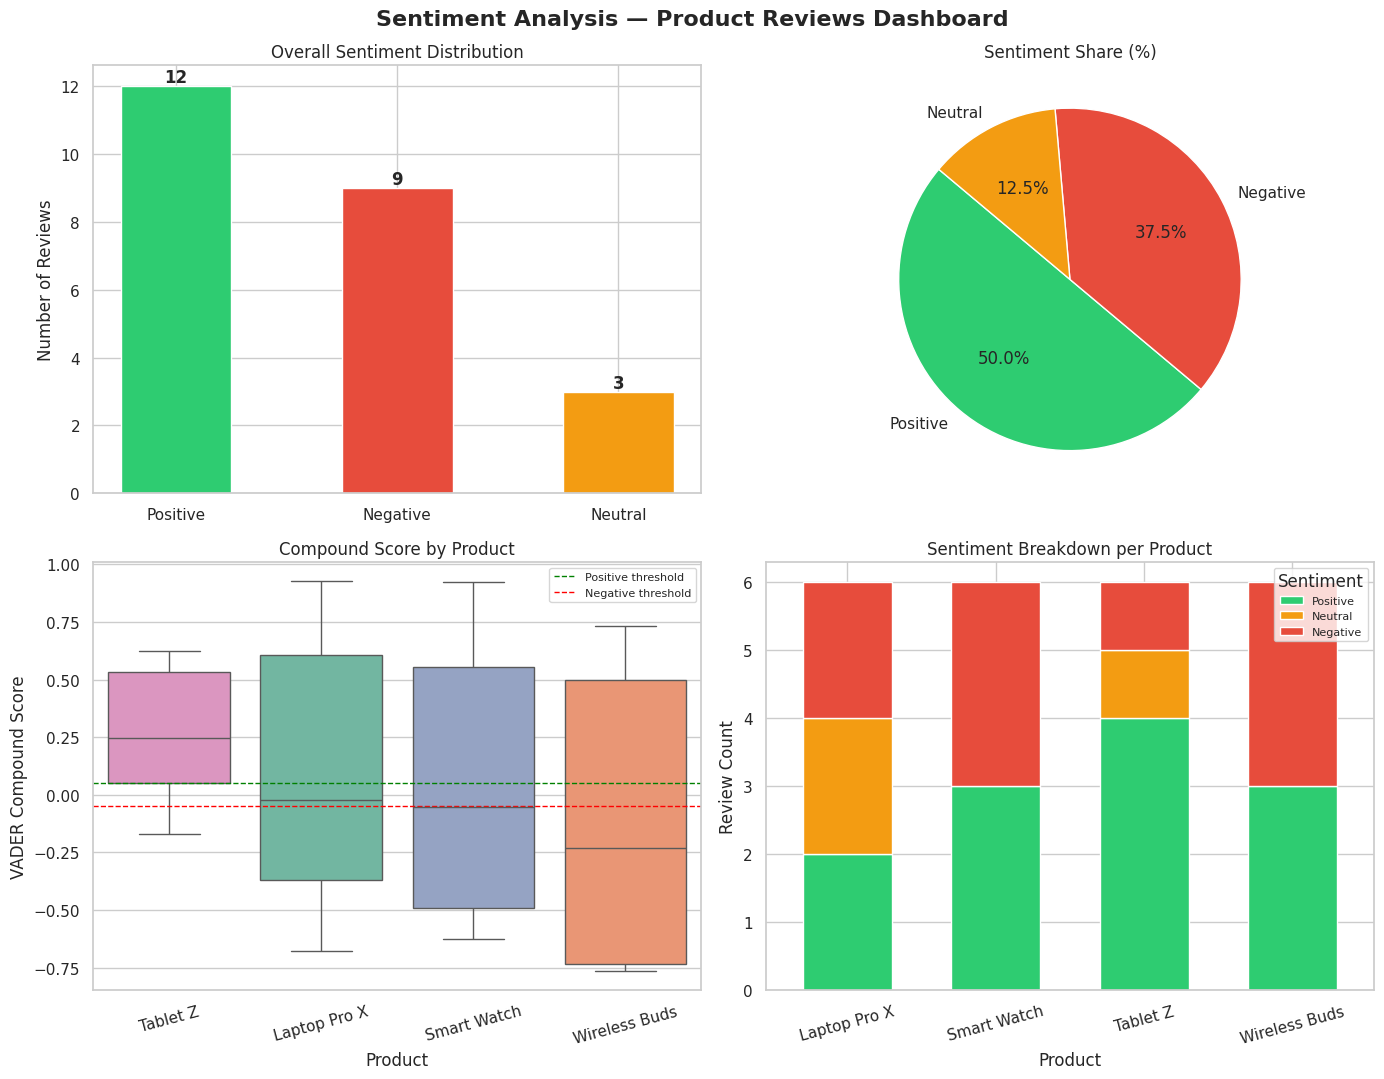


 Sentiment analysis complete. Plot saved as 'sentiment_analysis.png'.
 Results exported to 'sentiment_results.csv'.


In [ ]:
!pip install vaderSentiment
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# 1. Sample Review Dataset
reviews_raw = [
    # Positive
    ("Laptop Pro X",   "Absolutely love this laptop! Battery life is amazing and it's super fast."),
    ("Laptop Pro X",   "Best purchase I've made this year. Highly recommend to everyone!"),
    ("Wireless Buds",  "Crystal clear sound quality. Very comfortable to wear all day."),
    ("Wireless Buds",  "Fantastic earbuds! Noise cancellation is top-notch."),
    ("Smart Watch",    "Looks great and works perfectly. Very happy with this purchase."),
    ("Smart Watch",    "Excellent build quality. The fitness tracking is very accurate."),
    ("Tablet Z",       "Incredible display and smooth performance. Worth every penny!"),
    ("Tablet Z",       "Amazingly fast and lightweight. Great for travel."),
    # Negative
    ("Laptop Pro X",   "Terrible experience. Overheats constantly and crashes randomly."),
    ("Laptop Pro X",   "Very disappointed. Keyboard stopped working after two weeks."),
    ("Wireless Buds",  "Poor sound quality and the buds keep falling out. Waste of money."),
    ("Wireless Buds",  "Broke after one week. Extremely fragile and bad battery life."),
    ("Smart Watch",    "Horrible app support. The screen scratches too easily. Avoid!"),
    ("Smart Watch",    "Stopped charging after 3 days. Very frustrating product."),
    ("Tablet Z",       "Slow performance and the touch screen is unresponsive."),
    ("Tablet Z",       "Not worth the price. Constant software bugs and crashes."),
    # Neutral
    ("Laptop Pro X",   "It's an okay laptop. Nothing special but does the job."),
    ("Wireless Buds",  "Decent earbuds. Sound is average. Packaging was fine."),
    ("Smart Watch",    "The watch is okay. Works as described but nothing exceptional."),
    ("Tablet Z",       "Average tablet. Satisfactory for basic tasks like browsing."),
    ("Laptop Pro X",   "Arrived on time. Works as expected. Average product overall."),
    ("Wireless Buds",  "Not great, not terrible. Just a regular pair of earbuds."),
    ("Smart Watch",    "Standard smartwatch features. Battery life is neither good nor bad."),
    ("Tablet Z",       "It's fine. Does what you'd expect from a tablet at this price."),
]

df = pd.DataFrame(reviews_raw, columns=['Product', 'Review'])

# 2. Text Cleaning
def clean_text(text: str) -> str:
    """Lowercase and strip special characters (keep punctuation for VADER)."""
    text = text.lower().strip()
    text = re.sub(r'[^a-z0-9\s\.\!\?\,\']+', '', text)
    return text

df['Cleaned_Review'] = df['Review'].apply(clean_text)

# 3. VADER Sentiment Scoring
analyzer = SentimentIntensityAnalyzer()

def get_scores(text: str) -> dict:
    return analyzer.polarity_scores(text)

def classify_sentiment(compound: float) -> str:
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

scores_df = df['Cleaned_Review'].apply(
    lambda x: pd.Series(get_scores(x)))
df = pd.concat([df, scores_df], axis=1)
df['Sentiment'] = df['compound'].apply(classify_sentiment)

# 4. Console Output
print("=" * 65)
print("       SENTIMENT ANALYSIS — PRODUCT REVIEWS")
print("=" * 65)
print(df[['Product', 'Review', 'compound', 'Sentiment']]
      .to_string(index=False))

print("\n Sentiment Distribution:")
print(df['Sentiment'].value_counts().to_string())

print("\n Average Compound Score by Product:")
print(df.groupby('Product')['compound'].mean().round(3).to_string())

# 5. Visualizations
sns.set_theme(style='whitegrid')
color_map = {'Positive': '#2ecc71', 'Negative': '#e74c3c',
             'Neutral': '#f39c12'}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Sentiment Analysis — Product Reviews Dashboard",
             fontsize=16, fontweight='bold')

# 5a. Overall Sentiment Distribution (Count)
sentiment_counts = df['Sentiment'].value_counts()
bars = axes[0, 0].bar(sentiment_counts.index,
                       sentiment_counts.values,
                       color=[color_map[s] for s in sentiment_counts.index],
                       edgecolor='white', width=0.5)
for bar in bars:
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.1,
                    str(int(bar.get_height())),
                    ha='center', fontweight='bold')
axes[0, 0].set_title("Overall Sentiment Distribution")
axes[0, 0].set_ylabel("Number of Reviews")

# 5b. Pie Chart — Sentiment Share
axes[0, 1].pie(sentiment_counts,
               labels=sentiment_counts.index,
               autopct='%1.1f%%',
               colors=[color_map[s] for s in sentiment_counts.index],
               startangle=140,
               wedgeprops=dict(edgecolor='white'))
axes[0, 1].set_title("Sentiment Share (%)")

# 5c. Compound Score by Product (Box Plot)
product_order = (df.groupby('Product')['compound']
                   .median().sort_values(ascending=False).index)
sns.boxplot( data=df, x='Product', y='compound', hue='Product',
            order=product_order, palette='Set2',
            ax=axes[1, 0], legend=False,
            flierprops=dict(marker='o', markersize=4))
axes[1, 0].axhline(0.05, color='green', linestyle='--',
                    linewidth=1, label='Positive threshold')
axes[1, 0].axhline(-0.05, color='red', linestyle='--',
                    linewidth=1, label='Negative threshold')
axes[1, 0].set_title("Compound Score by Product")
axes[1, 0].set_ylabel("VADER Compound Score")
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].legend(fontsize=8)

# 5d. Stacked Bar — Sentiment per Product
sentiment_pivot = (df.groupby(['Product', 'Sentiment'])
                     .size().unstack(fill_value=0))
# Ensure consistent column order
for col in ['Positive', 'Neutral', 'Negative']:
    if col not in sentiment_pivot.columns:
        sentiment_pivot[col] = 0
sentiment_pivot = sentiment_pivot[['Positive', 'Neutral', 'Negative']]
sentiment_pivot.plot(
    kind='bar', stacked=True, ax=axes[1, 1],
    color=[color_map['Positive'],
           color_map['Neutral'],
           color_map['Negative']],
    edgecolor='white', width=0.6)
axes[1, 1].set_title("Sentiment Breakdown per Product")
axes[1, 1].set_xlabel("Product")
axes[1, 1].set_ylabel("Review Count")
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].legend(title='Sentiment', fontsize=8)

plt.tight_layout()
plt.savefig("sentiment_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n Sentiment analysis complete. Plot saved as 'sentiment_analysis.png'.")

# 6. Export Results to CSV
df[['Product', 'Review', 'neg', 'neu', 'pos',
    'compound', 'Sentiment']].to_csv(
    'sentiment_results.csv', index=False)
print(" Results exported to 'sentiment_results.csv'.")